In [1]:
# CELL 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# CELL 2: Create Unemployment Dataset
data = {
    'Region': ['Andhra Pradesh','Bihar','Delhi','Gujarat','Karnataka',
                'Kerala','Maharashtra','Punjab','Rajasthan','Tamil Nadu',
                'Uttar Pradesh','West Bengal','Madhya Pradesh','Odisha','Haryana'],
    'Date': ['2020-04-01']*15,
    'Frequency': ['Monthly']*15,
    'Estimated Unemployment Rate': [15.4, 46.6, 35.0, 17.5, 23.7,
                                     22.9, 20.9, 38.3, 27.1, 21.3,
                                     18.4, 43.1, 25.6, 20.8, 43.8],
    'Estimated Employed': [9279788, 31155966, 7151690, 24532775, 22551292,
                            11871761, 48920832, 10476869, 28732820, 31852365,
                            66287741, 37824014, 28273421, 18592232, 10619070],
    'Area': ['Rural','Rural','Urban','Rural','Urban',
              'Urban','Urban','Rural','Rural','Urban',
              'Rural','Rural','Rural','Rural','Urban']
}

df = pd.DataFrame(data)
print("Dataset Shape:", df.shape)
print(df.head())


Dataset Shape: (15, 6)
           Region        Date Frequency  Estimated Unemployment Rate  \
0  Andhra Pradesh  2020-04-01   Monthly                         15.4   
1           Bihar  2020-04-01   Monthly                         46.6   
2           Delhi  2020-04-01   Monthly                         35.0   
3         Gujarat  2020-04-01   Monthly                         17.5   
4       Karnataka  2020-04-01   Monthly                         23.7   

   Estimated Employed   Area  
0             9279788  Rural  
1            31155966  Rural  
2             7151690  Urban  
3            24532775  Rural  
4            22551292  Urban  


In [3]:
# CELL 3: Data Cleaning & Preprocessing
print("Missing Values:\n", df.isnull().sum())
print("\nDataset Info:")
print(df.describe())

Missing Values:
 Region                         0
Date                           0
Frequency                      0
Estimated Unemployment Rate    0
Estimated Employed             0
Area                           0
dtype: int64

Dataset Info:
       Estimated Unemployment Rate  Estimated Employed
count                    15.000000        1.500000e+01
mean                     28.026667        2.587484e+07
std                      10.481512        1.634976e+07
min                      15.400000        7.151690e+06
25%                      20.850000        1.124542e+07
50%                      23.700000        2.453278e+07
75%                      36.650000        3.150417e+07
max                      46.600000        6.628774e+07


/tmp/ipykernel_5835/568743844.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Estimated Unemployment Rate',


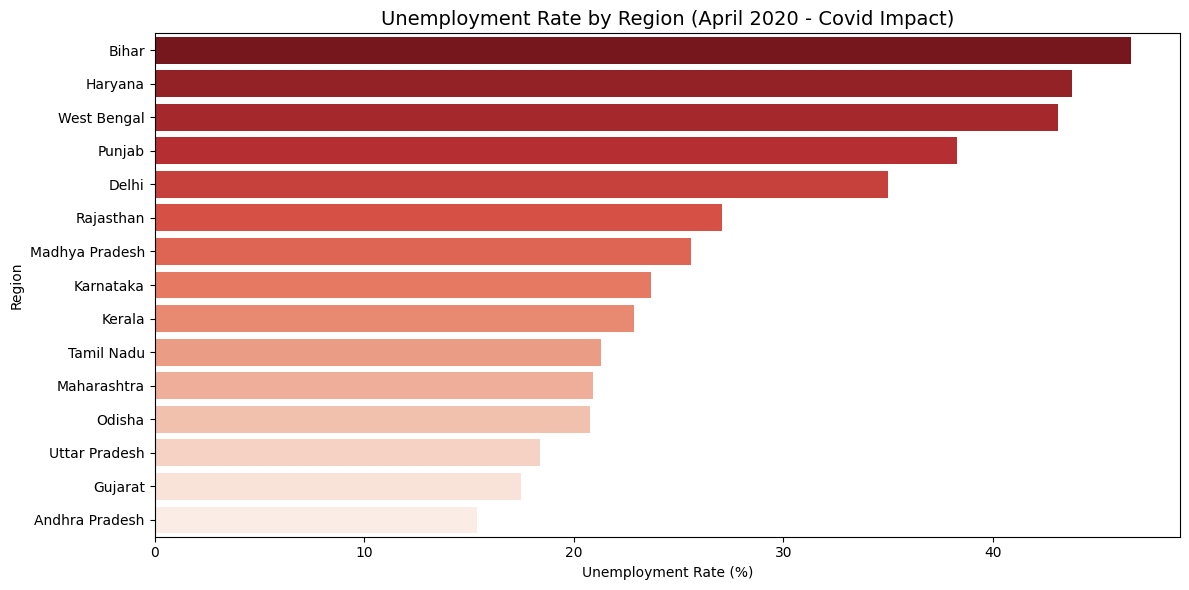

Plot 1 saved!


In [4]:
# CELL 4: Unemployment Rate by Region
plt.figure(figsize=(12, 6))
sns.barplot(x='Estimated Unemployment Rate',
            y='Region',
            data=df.sort_values('Estimated Unemployment Rate', ascending=False),
            palette='Reds_r')
plt.title('Unemployment Rate by Region (April 2020 - Covid Impact)', fontsize=14)
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Region')
plt.tight_layout()
plt.savefig('unemployment_by_region.png')
plt.show()
print("Plot 1 saved!")

/tmp/ipykernel_5835/1462808265.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Area',


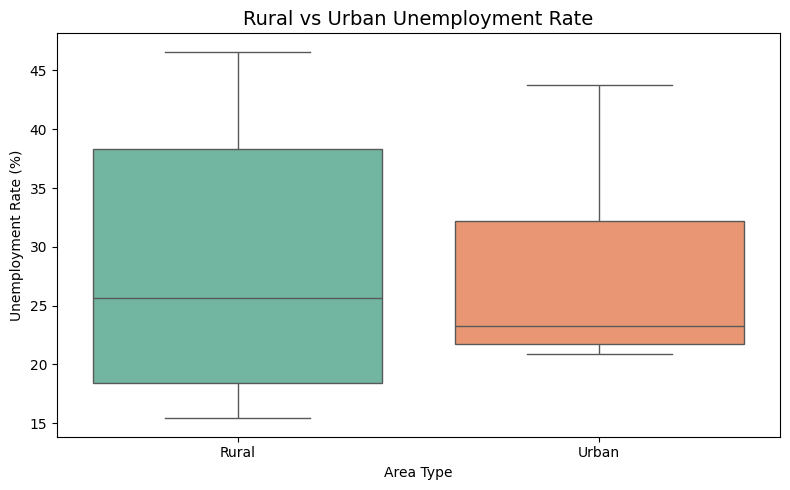

Plot 2 saved!


In [5]:
# CELL 5: Rural vs Urban Unemployment
plt.figure(figsize=(8, 5))
sns.boxplot(x='Area',
            y='Estimated Unemployment Rate',
            data=df,
            palette='Set2')
plt.title('Rural vs Urban Unemployment Rate', fontsize=14)
plt.xlabel('Area Type')
plt.ylabel('Unemployment Rate (%)')
plt.tight_layout()
plt.savefig('rural_vs_urban.png')
plt.show()
print("Plot 2 saved!")

/tmp/ipykernel_5835/103559352.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Region',


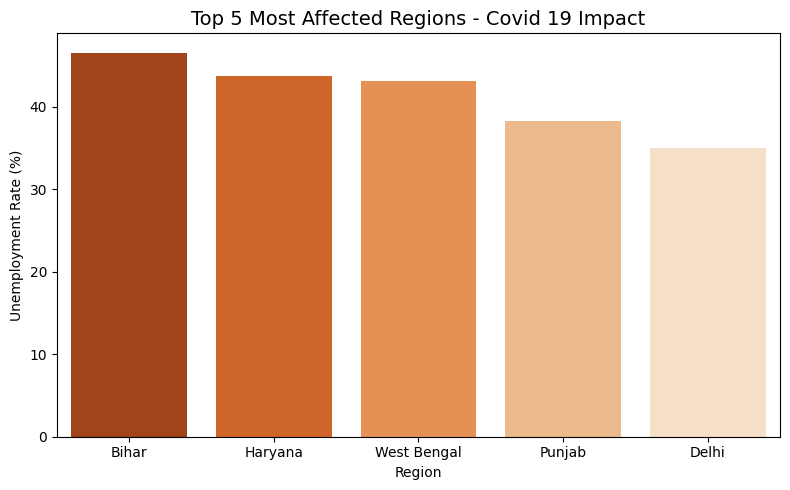

Plot 3 saved!


In [6]:
# CELL 6: Top 5 Most Affected Regions
plt.figure(figsize=(8, 5))
top5 = df.nlargest(5, 'Estimated Unemployment Rate')
sns.barplot(x='Region',
            y='Estimated Unemployment Rate',
            data=top5,
            palette='Oranges_r')
plt.title('Top 5 Most Affected Regions - Covid 19 Impact', fontsize=14)
plt.xlabel('Region')
plt.ylabel('Unemployment Rate (%)')
plt.tight_layout()
plt.savefig('top5_regions.png')
plt.show()
print("Plot 3 saved!")


In [7]:
# CELL 7: Key Insights
print("=" * 50)
print("KEY INSIGHTS - Unemployment Analysis")
print("=" * 50)
print(f"Highest Unemployment: {df.loc[df['Estimated Unemployment Rate'].idxmax(), 'Region']} "
      f"({df['Estimated Unemployment Rate'].max()}%)")
print(f"Lowest Unemployment:  {df.loc[df['Estimated Unemployment Rate'].idxmin(), 'Region']} "
      f"({df['Estimated Unemployment Rate'].min()}%)")
print(f"Average Unemployment: {df['Estimated Unemployment Rate'].mean():.2f}%")
print(f"\nRural Avg: {df[df['Area']=='Rural']['Estimated Unemployment Rate'].mean():.2f}%")
print(f"Urban Avg: {df[df['Area']=='Urban']['Estimated Unemployment Rate'].mean():.2f}%")


KEY INSIGHTS - Unemployment Analysis
Highest Unemployment: Bihar (46.6%)
Lowest Unemployment:  Andhra Pradesh (15.4%)
Average Unemployment: 28.03%

Rural Avg: 28.09%
Urban Avg: 27.93%


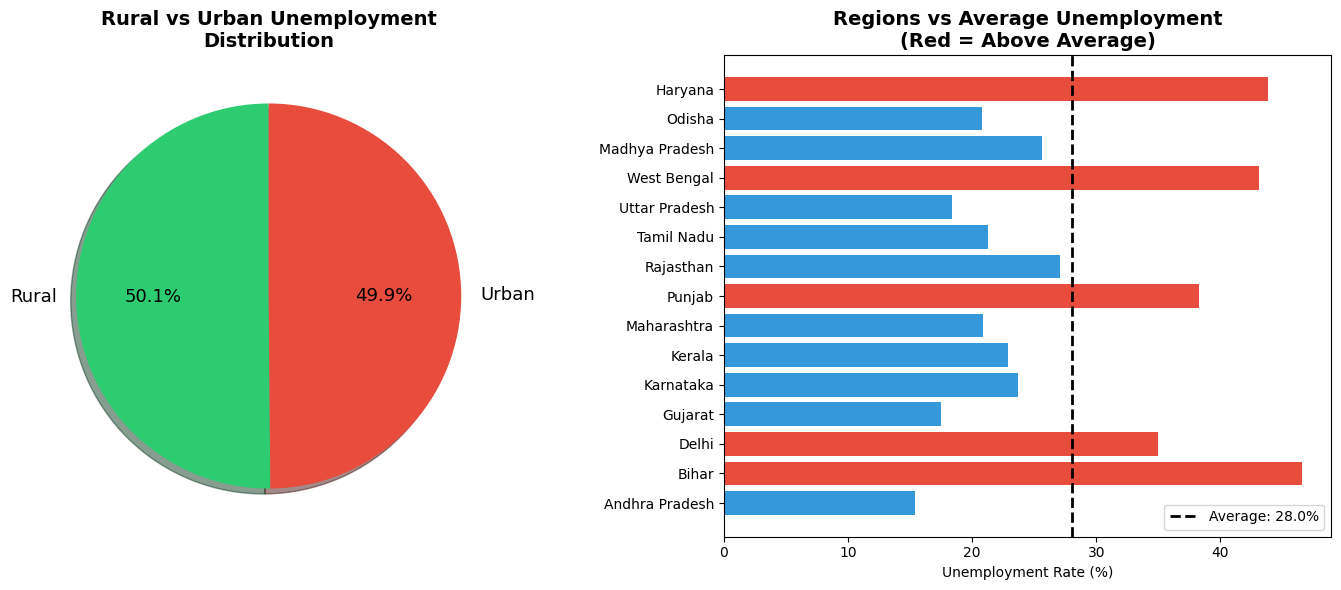

Elegant plots saved!


In [8]:
# CELL 8: Extra Visualizations - More Elegant!

# Plot 1: Pie Chart - Rural vs Urban Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie Chart
area_avg = df.groupby('Area')['Estimated Unemployment Rate'].mean()
axes[0].pie(area_avg, labels=area_avg.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90,
            shadow=True, textprops={'fontsize': 13})
axes[0].set_title('Rural vs Urban Unemployment\nDistribution', fontsize=14, fontweight='bold')

# Horizontal comparison bar
colors = ['#e74c3c' if x > 28 else '#3498db' for x in df['Estimated Unemployment Rate']]
axes[1].barh(df['Region'], df['Estimated Unemployment Rate'], color=colors)
axes[1].axvline(x=df['Estimated Unemployment Rate'].mean(),
                color='black', linestyle='--', linewidth=2, label=f'Average: {df["Estimated Unemployment Rate"].mean():.1f}%')
axes[1].set_title('Regions vs Average Unemployment\n(Red = Above Average)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Unemployment Rate (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('elegant_analysis.png', dpi=150)
plt.show()
print("Elegant plots saved!")